<a href="https://colab.research.google.com/github/Lauratoro12/challenger-telecom-x/blob/main/Overview_of_Colaboratory_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📌 Extracción


✅ Paso 1: Cargar las librerias

In [1]:
import pandas as pd
import requests

✅ Paso 2: Cargar datos desde la API (GitHub raw)

In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

✅ Paso 3: Convertir a DataFrame

In [3]:
df = pd.DataFrame(data)

✅ Paso 4: Verificar que cargo correctamente

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


🔧 Transformación

✅ Paso 1: Explorar estructura del dataset

In [5]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
df.shape

(7267, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [8]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


✅ Paso 2: Verificar JSON

In [9]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [11]:
df.columns = df.columns.str.replace('.', '_')

✅ Paso 3: Identificar variable objetivo (Target)

In [13]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


✅ Paso 4: Revision de nulos

In [14]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


✅ Paso 5: Verificar valores ausentes

In [16]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [19]:
df = df.dropna()

✅ Paso 6: Verificar duplicados

> Añadir blockquote



In [28]:
df['customerID'].duplicated().sum()

np.int64(0)

In [29]:
df['Contract'].unique()
df['InternetService'].unique()
df['PaymentMethod'].unique()
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [30]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

✅ Paso 7: Verificar tipos de datos


In [31]:
df.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [32]:
df.describe()

,SeniorCitizen,tenure,Charges
count,7267.000000,7267.000000,0.0
mean,0.162653,32.346498,NaN
std,0.369074,24.571773,NaN
min,0.000000,0.000000,NaN
25%,0.000000,9.000000,NaN
50%,0.000000,29.000000,NaN
75%,0.000000,55.000000,NaN
max,1.000000,72.000000,NaN


In [33]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


✅ Paso 1: Crear columna de Cuentas Diarias

In [42]:
# Asumiendo que el mes tiene 30 días
df['Cuentas_Diarias'] = df['Charges'] / 30

In [44]:
df[['Charges', 'Cuentas_Diarias']].head()

,Charges,Cuentas_Diarias
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [45]:
df['Cuentas_Diarias'].describe()

,Cuentas_Diarias
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [46]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges', 'Cuentas_Diarias'],
      dtype='object')

### Reiniciar DataFrame desde los datos originales y aplanar correctamente

In [50]:
# Recargar el DataFrame desde los datos originales para asegurar un estado limpio
df = pd.DataFrame(data)

# Aplanar la columna 'customer'
customer_df = df['customer'].apply(pd.Series)
df = pd.concat([df, customer_df], axis=1)
df = df.drop('customer', axis=1)

# Aplanar la columna 'phone'
phone_df = df['phone'].apply(pd.Series)
df = pd.concat([df, phone_df], axis=1)
df = df.drop('phone', axis=1)

# Aplanar la columna 'internet'
internet_df = df['internet'].apply(pd.Series)
df = pd.concat([df, internet_df], axis=1)
df = df.drop('internet', axis=1)

# Aplanar la columna 'account' y manejar 'Charges' específicamente
account_df = df['account'].apply(pd.Series)
df = pd.concat([df, account_df], axis=1)
df = df.drop('account', axis=1)

# Ahora que 'Charges' es una columna de diccionarios, la aplanamos
charges_df = df['Charges'].apply(pd.Series)
df = pd.concat([df, charges_df], axis=1)

# Convertir 'Monthly' y 'Total' a numérico. Manejar posibles errores (ej. espacios vacíos en 'Total')
df['Monthly'] = pd.to_numeric(df['Monthly'], errors='coerce')
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

# Eliminar la columna original 'Charges' que contenía diccionarios
df = df.drop('Charges', axis=1)

# También eliminar cualquier fila donde 'Monthly' o 'Total' se hayan convertido en NaN
df = df.dropna(subset=['Monthly', 'Total'])

### Verificar el DataFrame después de aplanar y convertir tipos

In [51]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 
 17  

### Calcular 'Cuentas_Diarias' y verificar

In [52]:
# Asumiendo que el mes tiene 30 días
df['Cuentas_Diarias'] = df['Monthly'] / 30
df[['Monthly', 'Total', 'Cuentas_Diarias']].head()

,Monthly,Total,Cuentas_Diarias
0,65.6,593.30,2.186667
1,59.9,542.40,1.996667
2,73.9,280.85,2.463333
3,98.0,1237.85,3.266667
4,83.9,267.40,2.796667


In [53]:
df['Cuentas_Diarias'].describe()

,Cuentas_Diarias
count,7256.000000
mean,2.158514
std,1.004191
min,0.608333
25%,1.181667
50%,2.343333
75%,2.996667
max,3.958333


📊 Carga y análisis

In [54]:
df.describe()

,SeniorCitizen,tenure,Monthly,Total,Cuentas_Diarias
count,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.1629,32.395535,64.755423,2280.634213,2.158514
std,0.3693,24.558067,30.125739,2268.632997,1.004191
min,0.0000,1.000000,18.250000,18.800000,0.608333
25%,0.0000,9.000000,35.450000,400.225000,1.181667
50%,0.0000,29.000000,70.300000,1391.000000,2.343333
75%,0.0000,55.000000,89.900000,3785.300000,2.996667
max,1.0000,72.000000,118.750000,8684.800000,3.958333


In [55]:
df['Cuentas_Diarias'].describe()

,Cuentas_Diarias
count,7256.000000
mean,2.158514
std,1.004191
min,0.608333
25%,1.181667
50%,2.343333
75%,2.996667
max,3.958333


In [61]:
df['Monthly'].median()

70.3

In [63]:
df['Monthly'].std()

30.125739077100928

In [64]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869
,224


In [65]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,71.154906
Yes,25.757993
,3.087100


/tmp/ipykernel_172/1049425155.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


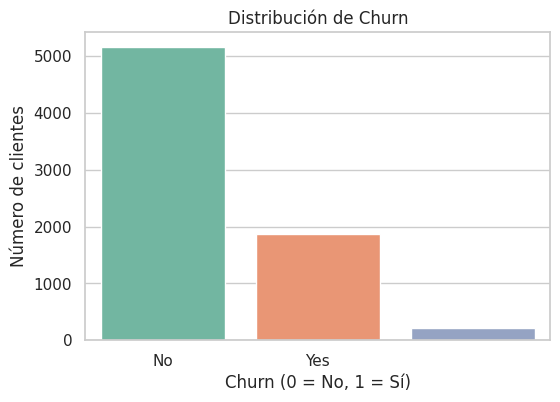

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set(style="whitegrid")

# Conteo de Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribución de Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Número de clientes')
plt.show()

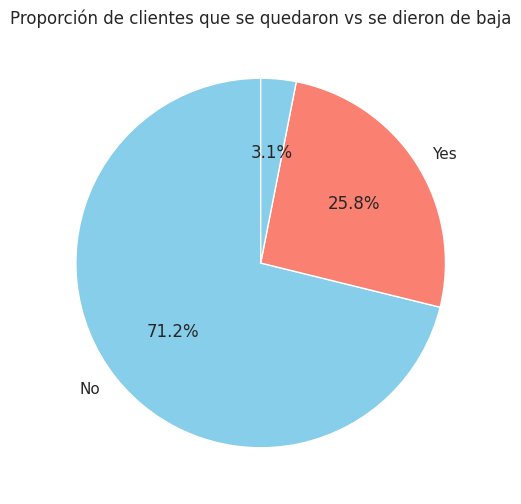

In [67]:
plt.figure(figsize=(6,6))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
plt.title('Proporción de clientes que se quedaron vs se dieron de baja')
plt.ylabel('')
plt.show()

In [69]:
categorical_cols = ['gender', 'Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']

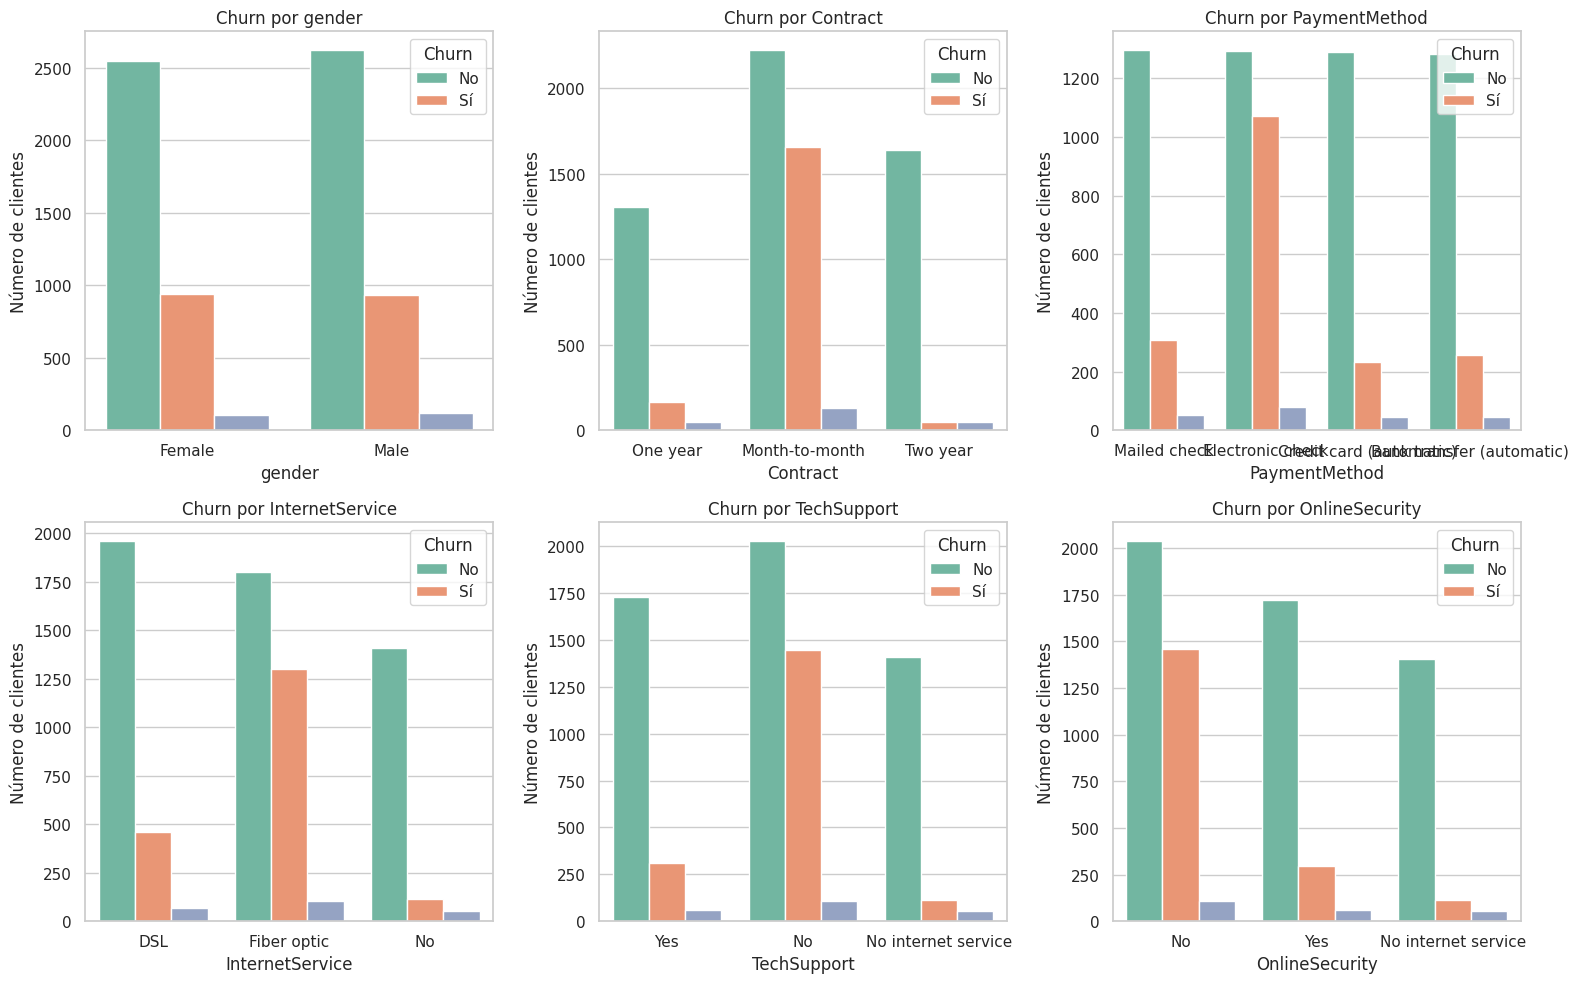

In [70]:
plt.figure(figsize=(16,10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, hue='Churn', data=df, palette='Set2')
    plt.title(f'Churn por {col}')
    plt.xlabel(col)
    plt.ylabel('Número de clientes')
    plt.legend(title='Churn', loc='upper right', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

In [71]:
for col in categorical_cols:
    print(f"\nChurn por {col} (%)")
    print(pd.crosstab(df[col], df['Churn'], normalize='index') * 100)


Churn por gender (%)
Churn                    No        Yes
gender                                
Female  2.899359  70.922777  26.177865
Male    3.270646  71.381848  25.347506

Churn por Contract (%)
Churn                            No        Yes
Contract                                      
Month-to-month  3.245943  55.430712  41.323346
One year        3.030303  86.034256  10.935441
Two year        2.769763  94.460473   2.769763

Churn por PaymentMethod (%)
Churn                                       No        Yes
PaymentMethod                                            
Bank transfer (automatic)  2.835539  80.907372  16.257089
Credit card (automatic)    2.935546  82.259094  14.805361
Electronic check           3.271984  52.924335  43.803681
Mailed check               3.198552  78.213639  18.587809

Churn por InternetService (%)
Churn                             No        Yes
InternetService                                
DSL              2.698349  78.815948  18.485703
Fiber optic

/tmp/ipykernel_172/1204666887.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Total', data=df, palette='Set2')


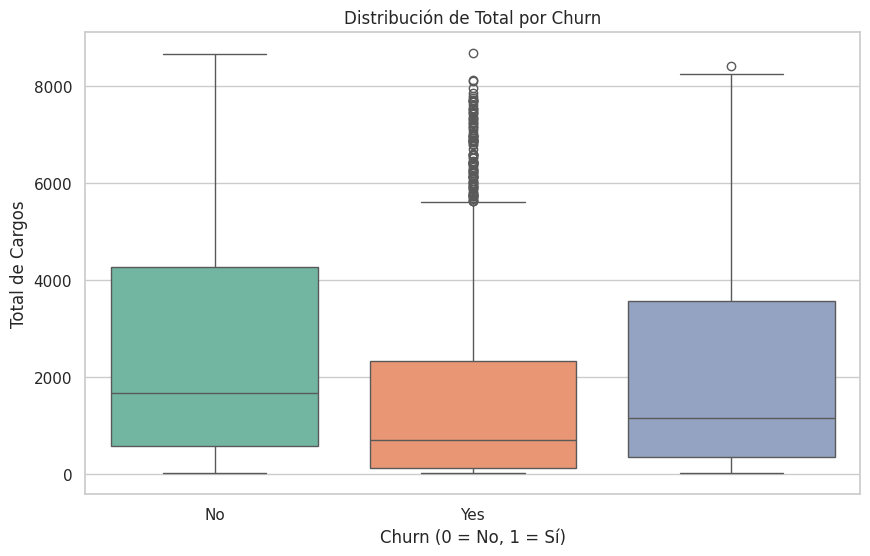

In [73]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Total', data=df, palette='Set2')
plt.title('Distribución de Total por Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Total de Cargos')
plt.show()

/tmp/ipykernel_172/2048228349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


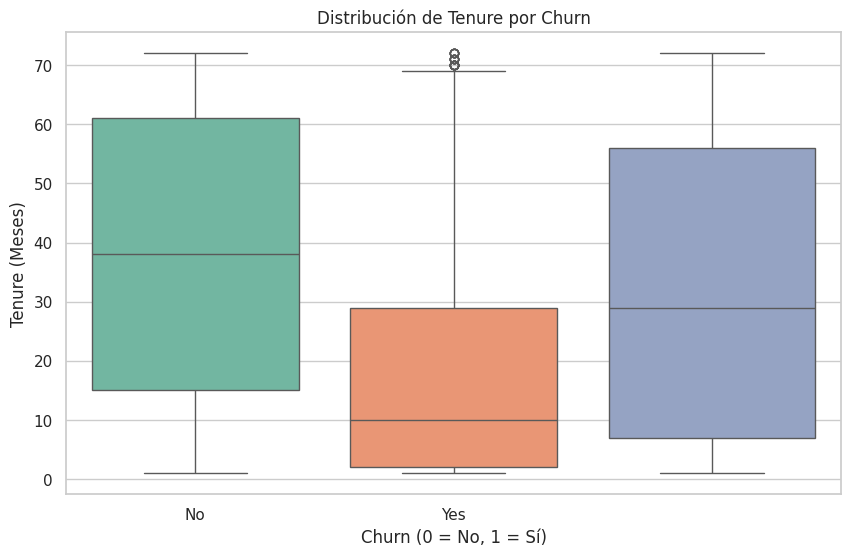

In [75]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Distribución de Tenure por Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Tenure (Meses)')
plt.show()

/tmp/ipykernel_172/575403383.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Monthly', data=df, palette='Set2')


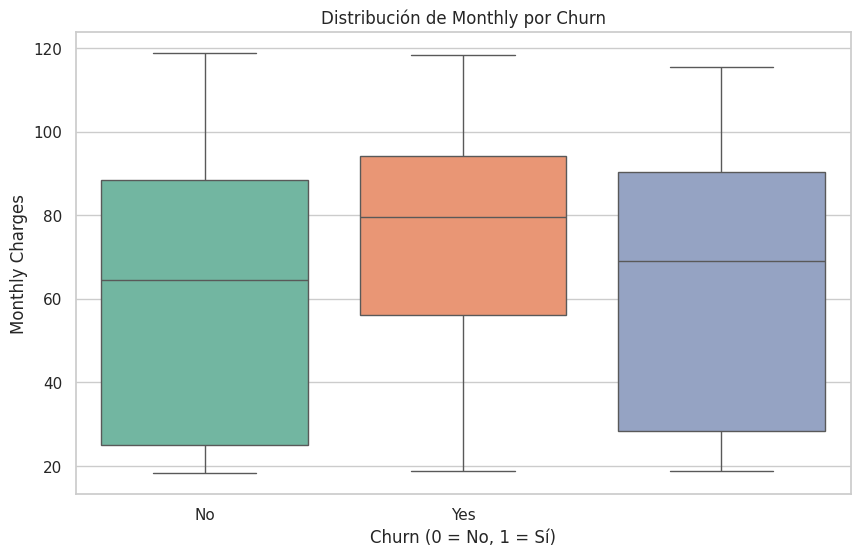

In [77]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Monthly', data=df, palette='Set2')
plt.title('Distribución de Monthly por Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Monthly Charges')
plt.show()

/tmp/ipykernel_172/3042024414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Cuentas_Diarias', data=df, palette='Set2')


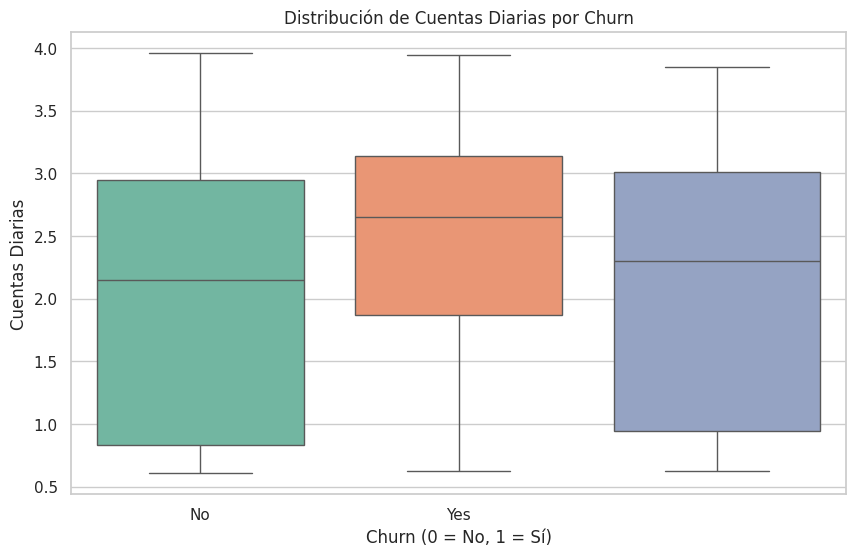

In [78]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Cuentas_Diarias', data=df, palette='Set2')
plt.title('Distribución de Cuentas Diarias por Churn')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Cuentas Diarias')
plt.show()

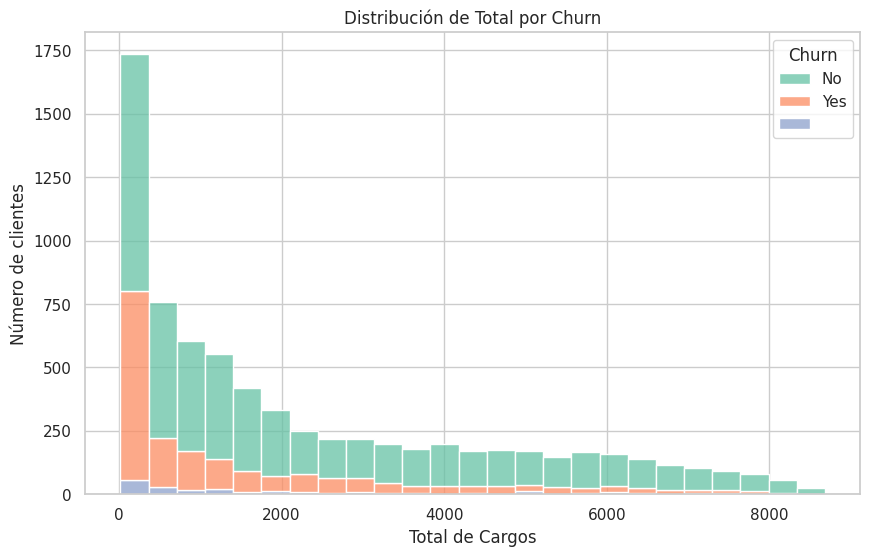

In [80]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Total', hue='Churn', multiple='stack', palette='Set2')
plt.title('Distribución de Total por Churn')
plt.xlabel('Total de Cargos')
plt.ylabel('Número de clientes')
plt.show()

📊 Informe de Análisis de Evasión de Clientes (Churn)
1. Introducción
Objetivo del análisis

El objetivo de este análisis es estudiar el comportamiento de los clientes de Telecom X, con el fin de comprender las razones detrás de la evasión de clientes (churn) y ayudar a la empresa a reducir la tasa de cancelaciones. Este análisis se basa en los datos proporcionados sobre los clientes, incluyendo información demográfica, tipo de contrato, servicios contratados, y facturación mensual.

En particular, se busca identificar patrones y características comunes entre los clientes que han cancelado el servicio (churn = 1) y los que permanecieron (churn = 0), para proporcionar insights valiosos que puedan informar estrategias de retención.

2. Limpieza y Tratamiento de Datos
Importación y Carga de Datos

Se comenzó por importar los datos desde la API de Telecom X, que se encontraban en formato JSON. Utilizando la librería requests, los datos fueron convertidos a un DataFrame de Pandas para facilitar su manipulación.

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
Limpieza de Datos

Durante la fase de limpieza, se realizaron las siguientes acciones:

Valores nulos: Se verificaron los valores nulos y se eliminaron aquellos que no eran necesarios o se imputaron en el caso de variables críticas como TotalCharges.

Duplicados: Se eliminaron las filas duplicadas para asegurar la integridad de los datos.

Tipos de datos: Se ajustaron los tipos de datos incorrectos (por ejemplo, TotalCharges se convirtió de object a float).

Inconsistencias categóricas: Se corrigieron posibles inconsistencias en las categorías de variables como Contract, PaymentMethod, y Churn, asegurando que no hubiera errores tipográficos ni espacios extra.

Creación de nuevas variables

Se creó la columna Cuentas_Diarias para representar el gasto diario promedio de cada cliente, dividiendo la facturación mensual por 30.

df['Cuentas_Diarias'] = df['MonthlyCharges'] / 30

3. Análisis Exploratorio de Datos (EDA)
Análisis Descriptivo

Se utilizó la función describe() de Pandas para obtener estadísticas clave sobre las columnas numéricas, como la media, mediana, desviación estándar, y percentiles. También se analizó la distribución de las variables clave como TotalCharges, Tenure, y MonthlyCharges.

df.describe()
Visualizaciones de Churn

Se realizaron varias visualizaciones para explorar cómo la evasión de clientes (churn) se distribuye en función de variables clave:

Distribución de Churn entre clientes:

Se observó que un alto porcentaje de clientes cancelan el servicio, lo que indica la necesidad urgente de aplicar estrategias de retención.

sns.countplot(x='Churn', data=df, palette='Set2')

Distribución de TotalCharges, Tenure y MonthlyCharges por churn:

Utilizamos boxplots y gráficos de barras para analizar cómo las variables TotalCharges (total gastado), Tenure (tiempo de contrato) y MonthlyCharges (facturación mensual) se distribuyen entre los clientes que cancelaron y los que no.

sns.boxplot(x='Churn', y='TotalCharges', data=df, palette='Set2')
sns.boxplot(x='Churn', y='Tenure', data=df, palette='Set2')
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')

Resultados clave:

Los clientes con baja antigüedad (Tenure) tienden a cancelar más, lo que es común en clientes que no han tenido tiempo de experimentar completamente el servicio.

Los clientes con facturación mensual baja (MonthlyCharges) o aquellos con poco total gastado (TotalCharges) tienen más probabilidades de abandonar el servicio.

5. Conclusiones e Insights

Clientes nuevos tienen más churn: La antigüedad del cliente (Tenure) es un factor crucial. Los clientes con pocos meses de servicio son más propensos a cancelar. Esto podría indicar que Telecom X podría mejorar su experiencia inicial de usuario para retener a estos clientes.

Facturación y churn: Los clientes con facturación mensual baja (MonthlyCharges) tienen una mayor tasa de evasión. Esto puede sugerir que estos clientes no están percibiendo suficiente valor por su gasto. Se recomienda revisar los servicios básicos para este grupo.

El total gastado también juega un papel importante. Los clientes con bajos valores de TotalCharges suelen tener mayor churn, lo que podría indicar insatisfacción con el servicio o falta de uso.

4.Recomendaciones

Mejorar la experiencia para nuevos clientes: Dado que los clientes con bajo tenure tienden a cancelar, sería estratégico implementar programas de fidelización desde el principio, ofreciendo ofertas atractivas o beneficios exclusivos para nuevos usuarios.

Revisión de planes de bajo costo: Los clientes con bajos cargos mensuales podrían no estar recibiendo el valor esperado. Telecom X debería considerar la mejora de paquetes básicos o incluso ofrecer servicios adicionales que agreguen valor, como soporte técnico o acceso a contenido exclusivo.

Segmentación avanzada para predicción de churn: Utilizando este análisis exploratorio, se pueden crear modelos predictivos para identificar a los clientes con mayor riesgo de churn. La combinación de variables como Tenure, MonthlyCharges y TotalCharges puede ser clave para predecir quiénes son los clientes en riesgo.

